# Question 3

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Part a)

Stock selection and data import. I selected the Moderna (MRNA) stock, which is a top 1000-sized stock (beforehands, I tested my code on the italian company Trivago (TRVG), which is much smaller).

In [11]:
taq = pd.read_csv('data/TAQ_MRNA_quotes_sep2025.csv')

Filter data:

In [12]:
import sys
sys.path.append('..')
from utils import filter_data_by_market_hours

In [13]:
tickers = taq['SYM_ROOT'].unique()
print(tickers)

<StringArray>
['MRNA']
Length: 1, dtype: str


In [14]:
taq_filtered = filter_data_by_market_hours(taq)

# print(taq_filtered.tail(20))

grouped = taq_filtered.groupby('DATE')

# print(grouped.head())

In [15]:
start_time = pd.Timedelta(hours=9, minutes=30)
end_time = pd.Timedelta(hours=16)
grid_times = pd.timedelta_range(start=start_time, end=end_time, freq='1min')

midpoints_by_day = {}

for date, group in grouped:
    group = group.sort_values('timedelta')
    # Filter out invalid quotes (BID <=0 or ASK <=0)
    group = group[(group['BID'] > 0) & (group['ASK'] > 0)]
    # Filter out bad quotes where spread is unreasonably large (> 1% of bid price)
    group = group[(group['ASK'] - group['BID']) / group['BID'] < 0.01]
    
    midpoints = []
    
    for grid_time in grid_times:
        before_quotes = group[group['timedelta'] <= grid_time]
        if not before_quotes.empty:
            last_quote = before_quotes.iloc[-1]
            midpoint = (last_quote['BID'] + last_quote['ASK']) / 2
        else:
            # For 09:30, if no before, use first quote of the day
            if grid_time == start_time:
                first_quote = group.iloc[0] if not group.empty else None
                if first_quote is not None:
                    midpoint = (first_quote['BID'] + first_quote['ASK']) / 2
                else:
                    midpoint = float('nan')
            else:
                # No quote before, set to NaN
                midpoint = float('nan')
        midpoints.append(midpoint)
    
    midpoints_series = pd.Series(midpoints, index=grid_times)
    midpoints_by_day[date] = midpoints_series

Debugging cell:

In [16]:
# MDRNA_midpoints = midpoints_by_day
# print(midpoints_by_day['02/09/2025'].loc[:])
# print(midpoints_by_day['02/09/2025'].to_numpy())
# print(midpoints_by_day['02/09/2025'].index.to_numpy())

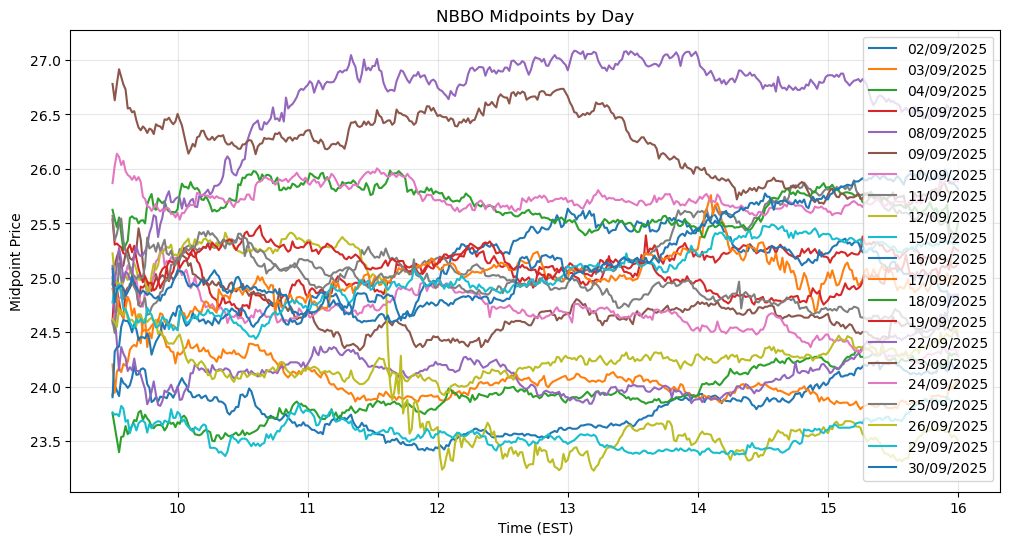

In [17]:
plt.figure(figsize=(12, 6))
for day, midpoints in midpoints_by_day.items():
    x_vals = midpoints.index.total_seconds() / 3600
    plt.plot(x_vals, midpoints, label = day)

plt.xlabel('Time (EST)')
plt.ylabel('Midpoint Price')
plt.legend()
plt.title('NBBO Midpoints by Day')
plt.grid(True, alpha=0.3)
plt.show()

## Part c)

Compute price differences and intraday variance curve

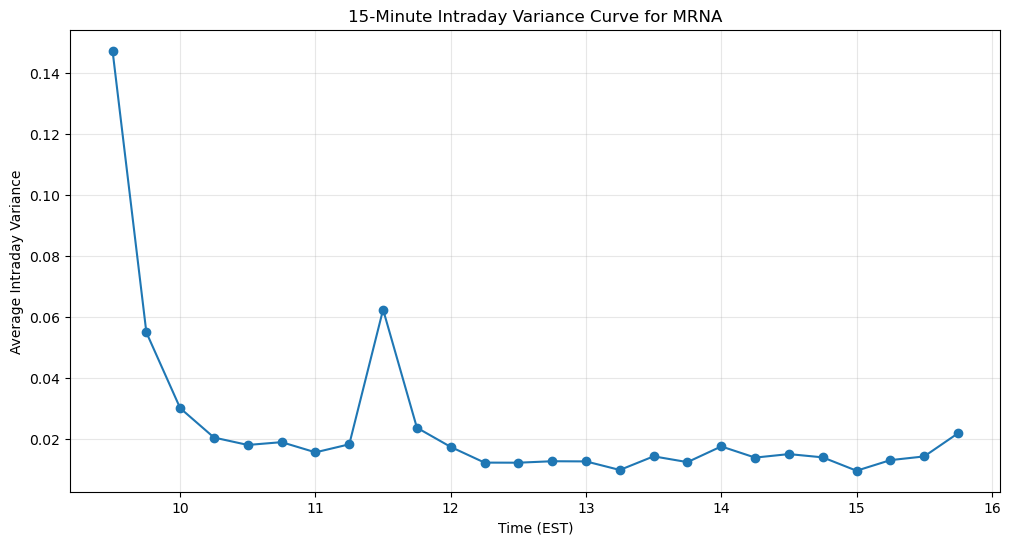

In [18]:

# print(midpoints_by_day['02/09/2025'].diff().dropna())

bin_duration = pd.Timedelta(minutes=15)
bins = []
current = start_time
while current < end_time:
    bins.append(current)
    current += bin_duration

variance_curve = {}
for bin_start in bins:
    bin_end = bin_start + bin_duration
    sum_sq_list = []
    for date, midpoints in midpoints_by_day.items():
        in_bin = (midpoints.index >= bin_start) & (midpoints.index < bin_end)
        midpoints_in_bin = midpoints.loc[in_bin]
        if len(midpoints_in_bin) > 1:
            diffs_in_bin = midpoints_in_bin.diff().dropna()
            sum_sq = (diffs_in_bin ** 2).sum()
            sum_sq_list.append(sum_sq)
    if sum_sq_list:
        avg_variance = np.mean(sum_sq_list)
    else:
        avg_variance = 0
    variance_curve[bin_start] = avg_variance

variance_series = pd.Series(variance_curve)

plt.figure(figsize=(12, 6))
x_vals = variance_series.index.total_seconds() / 3600
plt.plot(x_vals, variance_series.values, marker='o')
plt.xlabel('Time (EST)')
plt.ylabel('Average Intraday Variance')
plt.title('15-Minute Intraday Variance Curve for MRNA')
plt.grid(True, alpha=0.3)
plt.show()